# ANN Salary Regression

### From classification to regression

This notebook takes the same bank-customer dataset used for the ANN churn exercise and changes the question we are asking.

Instead of predicting **Exited (0/1)**, the model now predicts **EstimatedSalary**, which is a continuous numeric value.

> **Important:** This is a classroom learning exercise. The assignment itself says the result should not be treated as a production salary-estimation claim.

The workflow is deliberately kept close to the original churn workflow so the important changes are easy to see:
- target changes from `Exited` to `EstimatedSalary`
- the output layer changes from sigmoid to linear
- the loss changes from binary cross-entropy to MSE
- evaluation changes to MAE, RMSE and R²
- the same preprocessing used during training is saved for Streamlit deployment


## What changed from the churn ANN?

| Churn classification | Salary regression |
|---|---|
| Target: `Exited` | Target: `EstimatedSalary` |
| Output: sigmoid | Output: linear |
| Loss: binary cross-entropy | Loss: MSE |
| Accuracy / confusion matrix | MAE / RMSE / R² |
| Predicts a class/probability | Predicts a number |

The most important rule is **do not leave `EstimatedSalary` inside X**. If the answer is already inside the inputs, the model would simply be leaking the target.


## Step 1 — Imports

I am using **Matplotlib** for the notebook visualizations, as requested. No Seaborn is needed here.

`pickle` is used for saving the preprocessing objects because the same encoder and scaler must be reused by the Streamlit app.


In [5]:
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

pd.set_option("display.max_columns", None)

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.21.0


## Step 2 — Load and inspect the dataset

The assignment asks us to use the same `Churn_Modelling.csv` file from the classification exercise.

Keep the CSV in the same folder as this notebook before running it.


In [6]:

data = pd.read_csv('Churn_Modelling.csv')


print("Shape:", data.shape)
data.head()


Shape: (10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## Step 3 — EDA and data-quality checks

Before building a model, I want to know whether the data is complete and what the salary target looks like.

The checks below cover the items required in the assignment:
- shape
- data types and `info()`
- summary statistics
- missing values
- duplicate rows
- salary distribution


Shape: (10000, 14)
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.2 MB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
RowNumber,10000.0,NaN,NaN,NaN,5000.5,2886.89568,1.0,2500.75,5000.5,7500.25,10000.0
CustomerId,10000.0,NaN,NaN,NaN,15690940.5694,71936.186123,15565701.0,15628528.25,15690738.0,15753233.75,15815690.0
Surname,10000,2932,Smith,32,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CreditScore,10000.0,NaN,NaN,NaN,650.5288,96.653299,350.0,584.0,652.0,718.0,850.0
Geography,10000,3,France,5014,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,10000,2,Male,5457,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,10000.0,NaN,NaN,NaN,38.9218,10.487806,18.0,32.0,37.0,44.0,92.0
Tenure,10000.0,NaN,NaN,NaN,5.0128,2.892174,0.0,3.0,5.0,7.0,10.0
Balance,10000.0,NaN,NaN,NaN,76485.889288,62397.405202,0.0,0.0,97198.54,127644.24,250898.09
NumOfProducts,10000.0,NaN,NaN,NaN,1.5302,0.581654,1.0,1.0,1.0,2.0,4.0


,missing_values
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


0


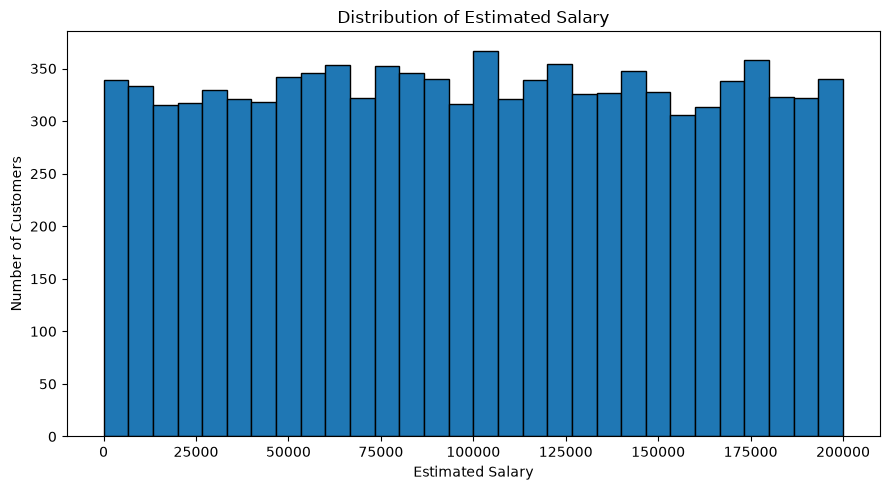

In [7]:
print("Shape:", data.shape)

data.info()

display(data.describe(include="all").T)

display(data.isnull().sum().to_frame("missing_values"))

print(data.duplicated().sum())

plt.figure(figsize=(9, 5))
plt.hist(data["EstimatedSalary"], bins=30, edgecolor="black")
plt.title("Distribution of Estimated Salary")
plt.xlabel("Estimated Salary")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()


## Step 4 — Define X and y

The identifiers (`RowNumber`, `CustomerId`, `Surname`) do not represent useful predictive information for this exercise, so they are removed.

Most importantly, `EstimatedSalary` becomes **y**, not X.

We also keep `Exited` out of the input features. It was the old classification target and is not needed for the salary-regression task.


In [8]:
df = data.drop(columns=["RowNumber", "CustomerId", "Surname"], errors="ignore").copy()

TARGET = "EstimatedSalary"

numeric_features = [
    "CreditScore",
    "Age",
    "Tenure",
    "Balance",
    "NumOfProducts",
    "HasCrCard",
    "IsActiveMember",
]

categorical_features = ["Geography", "Gender"]

X = df[numeric_features + categorical_features].copy()
y = df[TARGET].astype(float).copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

print(X.columns.tolist())


X shape: (10000, 9)
y shape: (10000,)
['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'Geography', 'Gender']


## Step 5 — Train/test split and preprocessing

This is an important part of the assignment.

The split happens **before** fitting the scaler and encoder. That prevents information from the test set from influencing the preprocessing.

For categorical columns:
- `Geography` and `Gender` are one-hot encoded.
- `drop="first"` avoids unnecessary duplicate information.

For numeric columns:
- `StandardScaler` puts the numeric inputs onto a comparable scale.


In [9]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
)

encoder = OneHotEncoder(
    drop="first",
    handle_unknown="ignore",
    sparse_output=False,
)

scaler = StandardScaler()

# Fit only on the training data.
encoder.fit(X_train_raw[categorical_features])
scaler.fit(X_train_raw[numeric_features])

def transform_features(frame):
    numeric_part = scaler.transform(frame[numeric_features])
    categorical_part = encoder.transform(frame[categorical_features])
    return np.hstack([numeric_part, categorical_part]).astype("float32")

X_train = transform_features(X_train_raw)
X_test = transform_features(X_test_raw)

print("Training shape:", X_train.shape)
print("Testing shape :", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape :", y_test.shape)

encoded_names = encoder.get_feature_names_out(categorical_features)
print("\nEncoded categorical columns:")
print(encoded_names.tolist())


Training shape: (8000, 10)
Testing shape : (2000, 10)
Training target shape: (8000,)
Testing target shape : (2000,)

Encoded categorical columns:
['Geography_Germany', 'Geography_Spain', 'Gender_Male']


## Step 6 — Build the regression ANN

The architecture stays simple on purpose.

The key change is the final layer:

```text
Dense(1, activation="linear")
```

A linear output can produce any real-valued salary. A sigmoid output would squeeze the answer into the range 0–1, which makes sense for a probability but not for a salary.


In [10]:
model = tf.keras.Sequential([
    tf.keras.Input(shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dropout(0.15),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(1, activation="linear"),
])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,817 (11.00 KB)

 Trainable params: 2,817 (11.00 KB)

 Non-trainable params: 0 (0.00 B)

## Step 7 — Compile and train

I am using:
- **Adam** as the optimizer
- **MSE (Mean Squared Error)** as the loss
- **MAE** as a useful additional regression metric

MSE is a natural choice for training a regression network because it strongly penalizes larger errors.

There is deliberately **no accuracy metric**, because accuracy is a classification metric and this model is predicting a continuous number.


Epoch 1/150
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 13308489728.0000 - mae: 99979.5234 - val_loss: 13695040512.0000 - val_mae: 102024.1172
Epoch 2/150
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 13218265088.0000 - mae: 99526.0391 - val_loss: 13496325120.0000 - val_mae: 101050.4062
Epoch 3/150
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 12864573440.0000 - mae: 97751.7891 - val_loss: 12939830272.0000 - val_mae: 98327.8438
Epoch 4/150
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 12106459136.0000 - mae: 93950.9688 - val_loss: 11931642880.0000 - val_mae: 93383.8828
Epoch 5/150
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 10925929472.0000 - mae: 88069.1016 - val_loss: 10522243072.0000 - val_mae: 86385.9688
Epoch 6/150
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 9429359616.0000 - mae: 80617.3516 - val_loss: 8883088384.0000 - val_mae: 78170.8438
Epoch 7/150
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 7854176768.0000 - mae: 72751.2422 - val_loss: 7272605184.

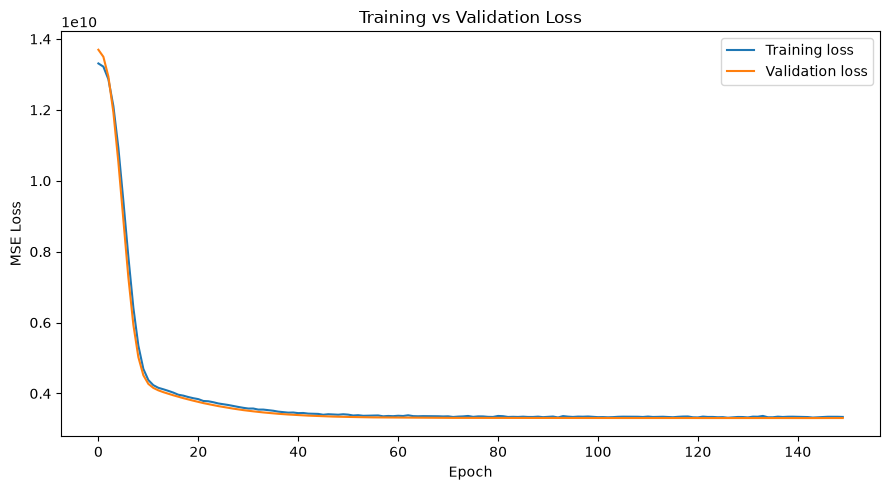

In [11]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="mse",
    metrics=[tf.keras.metrics.MeanAbsoluteError(name="mae")],
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True,
)

history = model.fit(
    X_train,
    y_train,
    validation_split=0.20,
    epochs=150,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1,
)

plt.figure(figsize=(9, 5))
plt.plot(history.history["loss"], label="Training loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.tight_layout()
plt.show()


## Step 8 — Evaluate on the untouched test set

The assignment specifically asks for:
- **MAE** — average absolute salary error
- **RMSE** — gives more weight to large errors
- **R²** — how much variation in the target is explained by the model

These are much more meaningful here than accuracy or a confusion matrix.


Test-set results
------------------------------
MAE :  49,978.41
RMSE:  57,704.21
R²  :  -0.0086


,Actual Salary,Predicted Salary
0,41788.37,99089.296875
1,146379.30,92605.476562
2,58561.31,95181.820312
3,170679.74,101332.726562
4,114669.79,97954.445312
5,149418.41,98705.546875
6,75685.97,104209.218750
7,70529.00,102715.718750
8,16618.76,98695.507812
9,164104.74,99029.320312


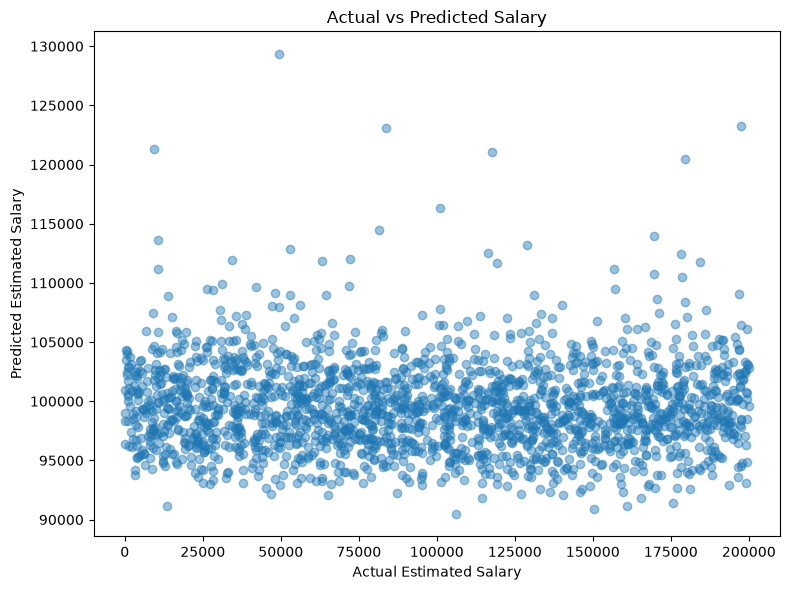

In [12]:
test_predictions = model.predict(X_test, verbose=0).ravel()

mae = mean_absolute_error(y_test, test_predictions)
rmse = np.sqrt(mean_squared_error(y_test, test_predictions))
r2 = r2_score(y_test, test_predictions)

print("Test-set results")
print("-" * 30)
print(f"MAE :  {mae:,.2f}")
print(f"RMSE:  {rmse:,.2f}")
print(f"R²  :  {r2:.4f}")

comparison = pd.DataFrame({
    "Actual Salary": y_test.to_numpy(),
    "Predicted Salary": test_predictions,
})
display(comparison.head(10))

plt.figure(figsize=(8, 6))
plt.scatter(y_test, test_predictions, alpha=0.45)
plt.xlabel("Actual Estimated Salary")
plt.ylabel("Predicted Estimated Salary")
plt.title("Actual vs Predicted Salary")
plt.tight_layout()
plt.show()


## Step 9 — Save and reload the model

The model alone is not enough for deployment.

The Streamlit app must perform the **same encoding and scaling** that were used during training. That is why the encoder, scaler, and feature order are saved separately with `pickle`.


In [13]:
MODEL_FILE = "salary_model.keras"
ENCODER_FILE = "encoder.pkl"
SCALER_FILE = "scaler.pkl"
FEATURE_ORDER_FILE = "feature_order.pkl"
METADATA_FILE = "metadata.pkl"

model.save(MODEL_FILE)

with open(ENCODER_FILE, "wb") as file:
    pickle.dump(encoder, file)

with open(SCALER_FILE, "wb") as file:
    pickle.dump(scaler, file)

feature_order = numeric_features + encoder.get_feature_names_out(
    categorical_features
).tolist()

with open(FEATURE_ORDER_FILE, "wb") as file:
    pickle.dump(feature_order, file)

metadata = {
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "encoded_features": encoder.get_feature_names_out(categorical_features).tolist(),
    "feature_order": feature_order,
    "target": TARGET,
    "mae": float(mae),
    "rmse": float(rmse),
    "r2": float(r2),
}

with open(METADATA_FILE, "wb") as file:
    pickle.dump(metadata, file)

print("Saved:")
for filename in [
    MODEL_FILE,
    ENCODER_FILE,
    SCALER_FILE,
    FEATURE_ORDER_FILE,
    METADATA_FILE,
]:
    print(" -", filename)

reloaded_model = tf.keras.models.load_model(MODEL_FILE, compile=False)

# A small sanity check with one test example.
sample_prediction = reloaded_model.predict(X_test[:1], verbose=0).ravel()[0]
print(f"\nReloaded model prediction for one test row: {sample_prediction:,.2f}")


Saved:
 - salary_model.keras
 - encoder.pkl
 - scaler.pkl
 - feature_order.pkl
 - metadata.pkl

Reloaded model prediction for one test row: 99,089.29


## Step 10 — Streamlit deployment

The companion `app.py` loads:
- `salary_model.keras`
- `encoder.pkl`
- `scaler.pkl`

The app asks for the same raw input fields used during training, applies the saved preprocessing, and sends the resulting feature vector to the ANN.

### GitHub → Streamlit Community Cloud

1. Upload the project files to a GitHub repository.
2. Make sure the model and preprocessing artifacts are included.
3. Make sure `requirements.txt` is present.
4. Open Streamlit Community Cloud.
5. Choose **New app** and select the GitHub repository.
6. Set the main file to `app.py`.
7. Deploy.

The repository also includes `train_model.py`, which can regenerate all artifacts from the real `Churn_Modelling.csv`.


## Reflection Questions

### 1. Why did we remove sigmoid from the output layer?
Because salary is a continuous numeric value. Sigmoid limits the output to 0–1, while a linear neuron can produce the full range of salary values.

### 2. Why is Binary Cross-Entropy not suitable here?
Binary cross-entropy is designed for classification probabilities. Our target is a continuous salary, so a regression loss such as MSE is appropriate.

### 3. What does MAE mean in salary units?
If MAE is, for example, 18,000, the model's predictions are off by about 18,000 salary units on average.

### 4. If RMSE is much larger than MAE, what might that suggest?
It can suggest that a smaller number of observations have relatively large prediction errors, because RMSE penalizes large errors more heavily.

### 5. What limitations would stop this from being a real banking salary model?
This is a classroom dataset and contains limited information. Salary is affected by many factors that are not represented here, and the dataset itself should not be treated as a complete or reliable salary-estimation source for real banking decisions.


## Final checklist

Before submission, confirm:

- [ ] `Churn_Modelling.csv` is the actual assignment dataset.
- [ ] Notebook runs from start to finish without errors.
- [ ] `EstimatedSalary` is not included in X.
- [ ] Output layer uses one neuron with linear activation.
- [ ] Loss is a regression loss.
- [ ] MAE, RMSE and R² are reported.
- [ ] Model is saved as `.keras`.
- [ ] Encoder and scaler are saved separately with `pickle`.
- [ ] `app.py` uses the same preprocessing order.
- [ ] `requirements.txt` is present.
- [ ] GitHub repository is complete.
- [ ] Streamlit app is tested before the final link is submitted.
